In [1]:
import sys
import pandas as pd
import numpy as np  
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from api_ingestion import read_json, clean_data_api

#get path for dataframes
BASE_DIR = Path().resolve().parent  # if inside analysis folder
DATA_PATH = BASE_DIR / "data" / "valid_data.csv"
df = pd.read_csv(DATA_PATH)
DATA_PATH = BASE_DIR / "data" / "unemployment_data_seed.json"
u_df = read_json(DATA_PATH)
u_df = clean_data_api(u_df)
#print(df.dtypes)
print(u_df.dtypes)

state_fips            string
state                 string
date          datetime64[us]
value                float64
dtype: object


In [2]:
df_avg = (
    df.groupby(['indicator', 'group', 'subgroup'])['value']
    .mean()
    .reset_index()
)


In [32]:
df_avg['indicator'].unique()
df_avg['group'].unique()

<StringArray>
[                                       'By Age',
                          'By Disability status',
                                  'By Education',
                            'By Gender identity',
 'By Presence of Symptoms of Anxiety/Depression',
                    'By Race/Hispanic ethnicity',
                                        'By Sex',
                         'By Sexual orientation',
                                      'By State',
                             'National Estimate']
Length: 10, dtype: str

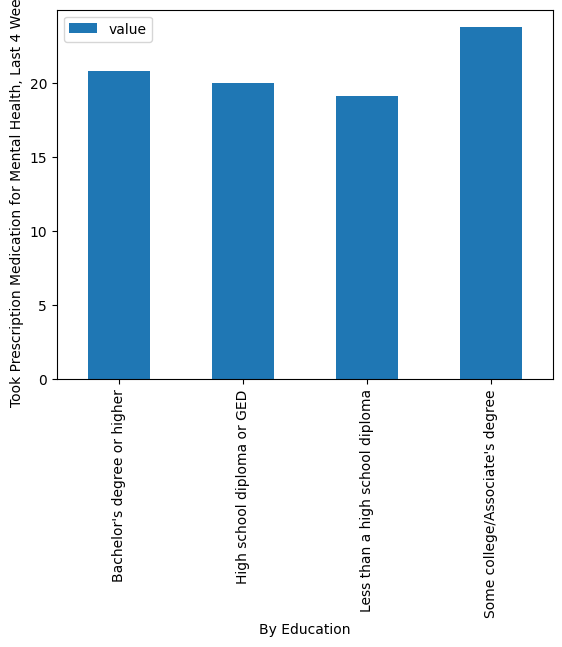

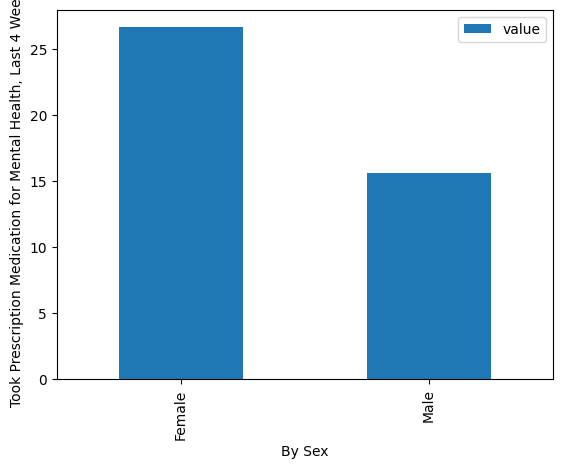

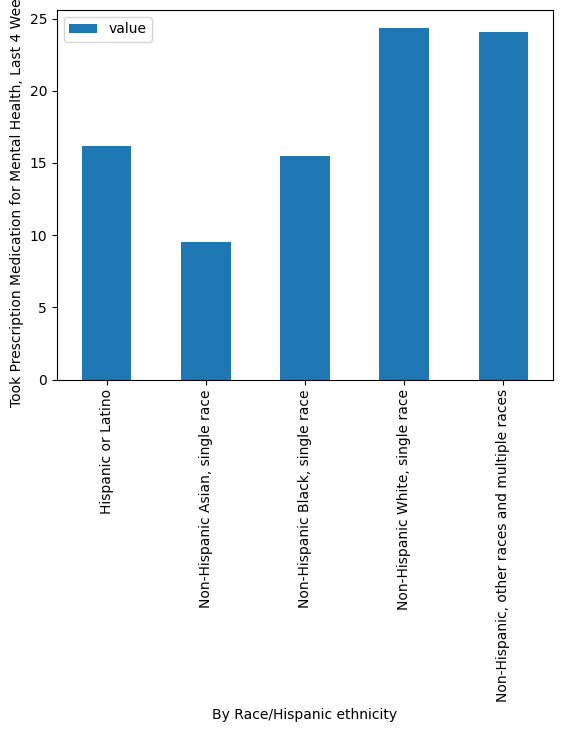

In [ ]:
NEED_COUNSELING_BUT_NOT_RECEIVED_INDICATOR = 'Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks'
TOOK_PRESCRIPTION_INDICATOR = "Took Prescription Medication for Mental Health, Last 4 Weeks"

def check_indicator(df, indicator = TOOK_PRESCRIPTION_INDICATOR, ascending=True, nlimit = 10):
    df_indicator = df[df['indicator'] == indicator]
    return df_indicator.sort_values(by='value', ascending=ascending).head(10)

def histogram(df, group, indicator = TOOK_PRESCRIPTION_INDICATOR):
    df_group = df[df['indicator'] == indicator]
    df_group = df_group[df_group['group'] == group]
    df_group = df_group[['subgroup','value']]
    df_group = df_group.set_index('subgroup')
    df_group.plot(kind='bar', xlabel= group)
    
    plt.ylabel(indicator)
    plt.xlabel(group,rotation = 45)

    plt.show()

histogram(df_avg, 'By Education')
histogram(df_avg, 'By Sex')
histogram(df_avg, 'By Race/Hispanic ethnicity')